# Тема 1. Моделирование геометрической вероятности
Смоделируйте вычисление геометрической вероятности (на примере из лекции про метание дротиков в игровой круг, площадь которого в два раза меньше площади стены). Показать теоретический расчет и графическую иллюстрацию для рассматриваемого примера.
> Задача: три точки на окружности.

> Условие: на окружности случайным образом и независимо выбираются три точки $A$, $B$ и $C$. Найти вероятность того, что центр окружности находится внутри образовавшегося треугольника $ABC$.

In [79]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

x = sp.Symbol('x')
pi = sp.pi

integrand = ((pi - x) / (2 * pi)) * (1 / pi)

P_theoretical_symbolic = sp.integrate(integrand, (x, 0, pi))

P_theory = float(P_theoretical_symbolic)

print(f"Теоретическая вероятность: {P_theory:.4f}")

Теоретическая вероятность: 0.2500


In [82]:
import numpy as np

N = 100_000

angles = np.random.uniform(0, 2 * np.pi, size=(N, 3))
angles.sort(axis=1)

# размеры дуг между соседними точками
g1 = angles[:, 1] - angles[:, 0]
g2 = angles[:, 2] - angles[:, 1]
g3 = 2 * np.pi - (angles[:, 2] - angles[:, 0])

# Центр внутри треугольника, если ни одна из дуг не превышает 180 градусов
inside = (g1 < np.pi) & (g2 < np.pi) & (g3 < np.pi)

P_sim = np.sum(inside) / N

print(f"Успешных случаев: {np.sum(inside)} из {N}")
print(f"Моделируемая вероятность: {P_sim:.4f}")

Успешных случаев: 25270 из 100000
Моделируемая вероятность: 0.2527


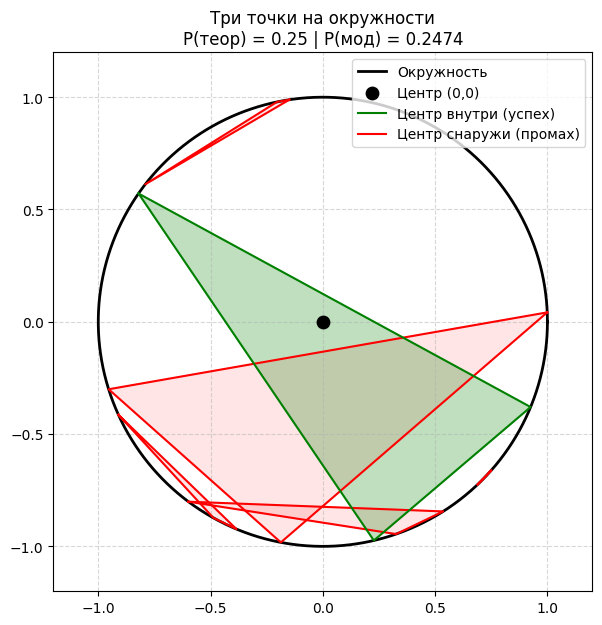

In [81]:
fig, ax = plt.subplots(figsize=(7, 7))

t = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(t), np.sin(t), color='black', linewidth=2, label='Окружность')
ax.scatter(0, 0, color='black', s=80, zorder=5, label='Центр (0,0)')

sample_angles = angles[:6]
sample_inside = inside[:6]

for pts, is_inside in zip(sample_angles, sample_inside):
    x_pts = np.cos(pts)
    y_pts = np.sin(pts)
    
    color = 'green' if is_inside else 'red'
    alpha = 0.25 if is_inside else 0.1
    
    ax.fill(x_pts, y_pts, color=color, alpha=alpha)
    ax.plot(np.append(x_pts, x_pts[0]), np.append(y_pts, y_pts[0]), color=color, linewidth=1.5)

ax.plot([], [], color='green', label='Центр внутри (успех)')
ax.plot([], [], color='red', label='Центр снаружи (промах)')

ax.set_aspect('equal')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)

ax.set_title(f"Три точки на окружности\nP(теор) = {P_theory:.2f} | P(мод) = {P_sim:.4f}")

ax.legend(loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()